<a href="https://colab.research.google.com/github/shirohigexe/practicas_HO_ML/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
mnist  = fetch_openml('mnist_784', as_frame=False)


In [2]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [3]:
X,y = mnist.data, mnist.target
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

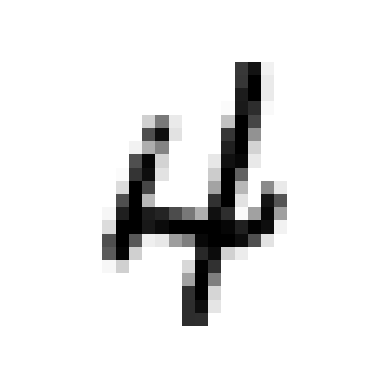

In [5]:
import matplotlib.pyplot as plt
import random

def plot_digit(image_data):
  image = image_data.reshape(28,28) #redimencionar
  plt.imshow(image, cmap='binary')
  plt.axis('off')
  plt.show()

random = random.randint(0,69999)
some_digit = X[random]
plot_digit(some_digit)

In [6]:
y[random]

'4'

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

esto es posible porque el dataset ya viene sep'arado y listo, debido a que es un dataset de juguete

## entrenando un clasificador binario
clasificaremos algo basico, suponiendo el nueve, de manera que será la clase 'nueve' y la clase 'no nueve'

In [8]:
y_train_9 = (y_train == '9') # True para todos los nueves, falso para el resto de digitos
y_test_9 = (y_test == '9')

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_9)


SGDClassifier(random_state=42)

In [10]:
sgd_clf.predict([some_digit])

array([False])

## Medidas de rendimiento

evaluar un clasificador es a menudo sigtnificativanebtre más complicado que evaluar un regresor

### Medidas de exactitud usando cross-validation

In [11]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9456 , 0.95195, 0.9509 ])

antes de sobre excaltar esors resultados, veamos un clasificador Dummy, que calsifica cada imagen en la más frecuente, que en este caso son los 'no-nueve'

In [12]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_9)
print(any(dummy_clf.predict(X_train)))

False


In [13]:
cross_val_score(dummy_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.90085, 0.90085, 0.90085])

ese 90% de exactitud es simplemente porque solo el 10% de las imagenes son 9, por lo tanto, hay un 90% de probabilidades de que aciertes a que un numero no es un 9

### Matriz de confusion

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3)

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_9, y_train_pred)
cm

array([[52715,  1336],
       [ 1695,  4254]])

In [16]:
y_train_perfect_predictions = y_train_9 #suponiendo la perfeccion
confusion_matrix(y_train_9, y_train_perfect_predictions)

array([[54051,     0],
       [    0,  5949]])

Para medir la precision usando la matriz de confusion usamos:
* precision = TP/(TP + FP)
* recall = TP/(TP + FN)
* F1 = 2 x [(precision x recall) / (precision + recall)]

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_9, y_train_pred)

# claro que se puede hacer de manera manual gracias a numpy
# cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.7610017889087657

In [18]:
recall_score(y_train_9, y_train_pred)

0.7150781643973777

In [19]:
from sklearn.metrics import f1_score

f1_score(y_train_9, y_train_pred)

0.737325591472398

ahora veremos un trade-off entre precision y recall

In [38]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([-3615.5050719])

In [39]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

para decidir el umbral una opcion es usar la siguiente funcion para conseguir puntajes de todas las instancias el el conjunto de entrenamiento

In [40]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3,
                             method="decision_function")

In [41]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_9, y_scores)

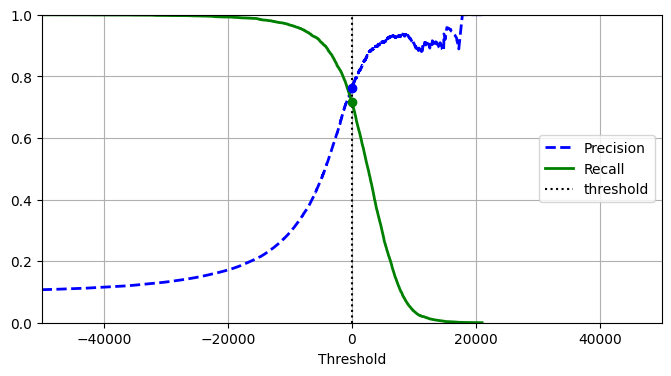

In [42]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

a continuacion, un ejemplo si quisieramos el valor excato para tener una precision mayor al 90% y como afecta al recall

In [45]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(4255.5613542876035)

In [46]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [47]:
precision_score(y_train_9, y_train_pred_90)

0.9001728608470182

In [49]:
recall_at_90_precision = recall_score(y_train_9, y_train_pred_90)
recall_at_90_precision

0.3501428811564969